## 1. Install Dependencies and Setup Environment

In [44]:
!pip install -q pyarrow

import os
import json
import pickle
import random
import warnings
import re
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    brier_score_loss
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.set_float32_matmul_precision("high")

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Load Datasets and Initial Validation

In [72]:
athletes = pd.read_csv("/content/athletes.csv")
daily    = pd.read_csv("/content/daily_data.csv")
activity = pd.read_csv("/content/activity_data.csv")

dup_mask = activity.duplicated(["athlete_id", "date"])

if dup_mask.any():
    print(f"Removing {dup_mask.sum()} duplicate rows from activity")

activity = activity.drop_duplicates(
    subset=["athlete_id", "date", "sport", "duration_minutes"]
)

print("athletes:", athletes.shape)
print("daily   :", daily.shape)
print("activity:", activity.shape)

daily["date"] = pd.to_datetime(daily["date"])
activity["date"] = pd.to_datetime(activity["date"])

for df_name, df in [("athletes", athletes), ("daily", daily), ("activity", activity)]:
    assert "athlete_id" in df.columns, f"{df_name} missing athlete_id"

assert "date" in daily.columns, "daily missing date"
assert "date" in activity.columns, "activity missing date"

Removing 108626 duplicate rows from activity
athletes: (1000, 26)
daily   : (366000, 15)
activity: (384153, 23)


## 3. Dataset Overview and Inspection

In [46]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print("\nATHLETES")
print(athletes.shape)
display(athletes.head())

print("\nDAILY")
print(daily.shape)
display(daily.head())

print("\nACTIVITY")
print(activity.shape)
display(activity.head())

DATASET OVERVIEW

ATHLETES
(1000, 26)


,athlete_id,gender,age,height_cm,weight_kg,genetic_factor,hrv_baseline,hrv_range,max_hr,resting_hr,...,training_experience,weekly_training_hours,recovery_rate,lifestyle,sleep_time_norm,sleep_quality,nutrition_factor,stress_factor,smoking_factor,drinking_factor
0,97edad40-801f-42c8-98fc-d0fce938c24f,female,35,164,57.7,0.91,97.5,"(np.float64(82.9), np.float64(112.1))",187.5,44.9,...,4,13.6,1.09,Highly Disciplined Athlete,7.733992,0.905808,0.986618,0.141615,0.0,0.060112
1,f1ba3d42-c1da-4a0b-b225-a73170e30907,male,28,174,78.5,0.94,108.0,"(np.float64(91.8), np.float64(124.2))",185.8,46.8,...,8,9.7,1.24,Highly Disciplined Athlete,8.314044,0.914092,0.980220,0.197377,0.0,0.007455
2,f2d777b2-3f53-4835-acbc-e6b979f1bf30,male,33,184,72.0,0.93,100.5,"(np.float64(85.4), np.float64(115.6))",187.3,39.7,...,10,10.9,1.23,Highly Disciplined Athlete,8.140662,0.981801,0.986073,0.102149,0.0,0.000695
3,ddd54236-24e5-4922-8750-131d79a39f9f,male,42,172,69.9,1.13,87.0,"(np.float64(74.0), np.float64(100.0))",177.3,52.9,...,7,16.0,1.27,Health-Conscious Athlete,8.068269,0.847450,0.865080,0.229927,0.0,0.149298
4,acb2760d-ee88-4753-9935-271c91381b91,male,36,171,64.7,1.14,96.0,"(np.float64(81.6), np.float64(110.4))",174.7,48.7,...,3,16.0,1.30,Highly Disciplined Athlete,8.930893,0.991486,0.937016,0.185664,0.0,0.001546



DAILY
(366000, 15)


,athlete_id,date,resting_hr,hrv,sleep_hours,deep_sleep,light_sleep,rem_sleep,sleep_quality,body_battery_morning,stress,body_battery_evening,planned_tss,actual_tss,injury
0,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-01,43.518730,103.162006,8.743521,1.348662,5.451481,1.943378,0.921,100.0,4.7,46.3,75,75.0,0
1,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-02,41.774490,103.266783,8.068680,1.259958,5.004577,1.804145,0.921,100.0,6.9,41.2,103,103.0,0
2,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-03,43.834551,101.900223,8.219197,1.215866,5.206451,1.796881,0.882,73.0,7.3,29.9,118,0.0,0
3,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-04,45.185704,101.138027,7.794236,1.301622,4.699527,1.793086,0.841,100.0,10.0,42.5,93,93.0,0
4,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-05,46.855634,92.094592,8.675780,1.309008,5.455251,1.911521,0.921,93.0,8.2,48.5,0,0.0,0



ACTIVITY
(384153, 23)


,athlete_id,date,sport,workout_type,duration_minutes,tss,intensity_factor,avg_hr,max_hr,hr_zones,...,normalized_power,power_zones,intensity_variability,work_kilojoules,elevation_gain,avg_pace_min_km,training_effect_aerobic,training_effect_anaerobic,distance_m,avg_pace_min_100m
0,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-01,swim,Threshold Swim,56.0,75.0,0.90,174,188,"{'Z1': 15.178571428571427, 'Z2': 4.01785714285...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.1,NaN,3629.685643,1.542833
1,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-02,bike,Endurance Ride,154.0,103.0,0.63,159,179,"{'Z1': 19.967532467532468, 'Z2': 42.2077922077...",...,119.0,"{'Z1': 31.006493506493506, 'Z2': 68.9935064935...",1.01,1090.0,373.0,NaN,NaN,NaN,NaN,NaN
2,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-04,run,Endurance Run,77.0,64.0,0.71,153,168,"{'Z1': 21.753246753246753, 'Z2': 78.2467532467...",...,NaN,NaN,NaN,NaN,128.0,5.99,1.4,1.0,NaN,NaN
3,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-04,swim,Easy Swim,70.0,29.0,0.50,122,133,"{'Z1': 99.64285714285714, 'Z2': 0.0, 'Z3': 0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,0.8,NaN,4401.131720,1.590500
4,97edad40-801f-42c8-98fc-d0fce938c24f,2024-01-06,swim,Speed Work,67.0,111.0,1.00,174,188,"{'Z1': 15.298507462686567, 'Z2': 3.35820895522...",...,NaN,NaN,NaN,NaN,NaN,NaN,1.5,NaN,4210.746831,1.591167


## 4. Data Types and Schema Analysis

In [47]:
for name, df in [("athletes", athletes), ("daily", daily), ("activity", activity)]:
    print("\n" + "="*60)
    print(name.upper())
    print("="*60)
    print(df.dtypes)


ATHLETES
athlete_id                 object
gender                     object
age                         int64
height_cm                   int64
weight_kg                 float64
genetic_factor            float64
hrv_baseline              float64
hrv_range                  object
max_hr                    float64
resting_hr                float64
lthr                        int64
hr_zones                   object
vo2max                    float64
running_threshold_pace    float64
ftp                       float64
css                       float64
training_experience         int64
weekly_training_hours     float64
recovery_rate             float64
lifestyle                  object
sleep_time_norm           float64
sleep_quality             float64
nutrition_factor          float64
stress_factor             float64
smoking_factor            float64
drinking_factor           float64
dtype: object

DAILY
athlete_id                      object
date                    datetime64[ns]
resting

## 5. Missing Value Analysis

In [48]:
for name, df in [("athletes", athletes), ("daily", daily), ("activity", activity)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]

    print("\n" + "="*60)
    print(f"{name.upper()} MISSING VALUES")
    print("="*60)

    if len(miss)==0:
        print("No missing values")
    else:
        print(miss.sort_values(ascending=False))


ATHLETES MISSING VALUES
No missing values

DAILY MISSING VALUES
No missing values

ACTIVITY MISSING VALUES
distance_m                   289049
avg_pace_min_100m            289049
avg_pace_min_km              279515
training_effect_anaerobic    279515
avg_power                    213320
intensity_variability        213320
work_kilojoules              213320
normalized_power             213320
power_zones                  213320
training_effect_aerobic      184411
elevation_gain               108682
avg_speed_kph                 13578
distance_km                   13578
dtype: int64


## 6. Statistical Summary of Features

In [49]:
for name, df in [("athletes", athletes), ("daily", daily), ("activity", activity)]:
    print("\n" + "="*60)
    print(f"{name.upper()} NUMERIC SUMMARY")
    print("="*60)
    display(df.describe())


ATHLETES NUMERIC SUMMARY


,age,height_cm,weight_kg,genetic_factor,hrv_baseline,max_hr,resting_hr,lthr,vo2max,running_threshold_pace,...,css,training_experience,weekly_training_hours,recovery_rate,sleep_time_norm,sleep_quality,nutrition_factor,stress_factor,smoking_factor,drinking_factor
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,32.55100,172.240000,66.665100,0.997030,101.173500,187.416300,47.262000,183.910000,69.299200,3.884620,...,90.465700,7.035000,12.009400,1.045650,7.205263,0.779062,0.802561,0.334416,0.005294,0.181316
std,5.84359,9.338716,11.552878,0.088423,8.765385,7.042738,5.237254,8.097621,5.532023,0.829432,...,7.011487,3.828372,2.464233,0.192786,1.039052,0.181030,0.147679,0.239346,0.017783,0.143084
min,18.00000,150.000000,37.200000,0.800000,75.000000,168.300000,38.000000,160.000000,50.000000,3.000000,...,78.500000,2.000000,8.000000,0.500000,5.000000,0.311255,0.400621,0.000032,0.000000,0.000079
25%,29.00000,165.000000,56.375000,0.940000,94.500000,182.900000,43.500000,179.750000,66.400000,3.090000,...,85.300000,4.000000,10.000000,0.900000,6.539458,0.672821,0.706499,0.142936,0.000000,0.068224
50%,33.00000,172.000000,67.550000,1.000000,100.500000,187.200000,47.100000,188.000000,70.000000,3.700000,...,89.300000,6.000000,11.900000,1.065000,7.361411,0.821855,0.817452,0.279448,0.000000,0.141126
75%,37.00000,179.000000,76.125000,1.060000,106.500000,192.100000,50.800000,190.000000,75.000000,4.490000,...,95.000000,10.000000,13.925000,1.210000,7.947765,0.932232,0.931257,0.497318,0.000000,0.283080
max,50.00000,200.000000,94.600000,1.200000,123.000000,217.900000,60.000000,190.000000,75.000000,5.500000,...,114.200000,20.000000,16.000000,1.300000,8.998189,0.999997,0.999714,0.897510,0.097477,0.595048



DAILY NUMERIC SUMMARY


,date,resting_hr,hrv,sleep_hours,deep_sleep,light_sleep,rem_sleep,sleep_quality,body_battery_morning,stress,body_battery_evening,planned_tss,actual_tss,injury
count,366000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000,366000.000000
mean,2024-07-01 12:00:00,50.931118,91.355231,7.260289,1.072903,4.607539,1.579847,0.748752,81.833313,26.554134,26.092949,90.929246,71.019047,0.081426
min,2024-01-01 00:00:00,32.994728,46.800000,4.000000,0.320000,2.369110,0.574941,0.304000,47.157962,0.000000,5.000000,0.000000,0.000000,0.000000
25%,2024-04-01 00:00:00,46.536199,84.150000,6.491807,0.917616,4.149766,1.388036,0.682000,72.000000,17.800000,15.100000,61.000000,9.000000,0.000000
50%,2024-07-01 12:00:00,50.625071,90.978711,7.369632,1.084353,4.664915,1.602687,0.802000,83.000000,24.800000,26.600000,89.000000,68.000000,0.000000
75%,2024-10-01 00:00:00,55.031642,98.175000,8.102665,1.231589,5.105863,1.784770,0.841000,95.000000,34.900000,35.200000,120.000000,106.000000,0.000000
max,2024-12-31 00:00:00,69.000000,141.450000,10.855088,1.870023,7.226689,2.478064,0.960000,100.000000,95.000000,60.000000,710.000000,774.500000,1.000000
std,NaN,6.047616,10.310273,1.157197,0.220491,0.702286,0.278978,0.150331,14.037619,11.772830,12.755282,55.321304,59.746032,0.273489



ACTIVITY NUMERIC SUMMARY


,date,duration_minutes,tss,intensity_factor,avg_hr,max_hr,distance_km,avg_speed_kph,avg_power,normalized_power,intensity_variability,work_kilojoules,elevation_gain,avg_pace_min_km,training_effect_aerobic,training_effect_anaerobic,distance_m,avg_pace_min_100m
count,384153,384153.000000,384153.000000,384153.000000,384153.000000,384153.000000,370575.000000,370575.000000,170833.000000,170833.000000,170833.000000,170833.000000,275471.000000,104638.000000,199742.000000,104638.000000,95104.000000,95104.000000
mean,2024-07-02 03:29:00.778283776,84.396350,67.663070,0.694355,152.039055,167.945373,31.993761,18.819375,153.832011,156.036954,1.013121,1012.751459,236.968490,5.349051,1.122879,0.901491,3558.347679,1.547056
min,2024-01-01 00:00:00,2.000000,1.000000,0.400000,101.000000,107.000000,0.282592,3.000250,57.000000,57.000000,1.000000,75.000000,10.000000,2.700000,0.100000,0.100000,282.592313,1.242000
25%,2024-04-02 00:00:00,49.000000,38.000000,0.630000,137.000000,152.000000,5.106681,4.440059,116.000000,117.000000,1.000000,576.000000,124.000000,4.330000,0.700000,1.000000,2702.985856,1.454000
50%,2024-07-04 00:00:00,68.000000,60.400000,0.630000,155.000000,174.000000,20.330000,14.400000,148.000000,150.000000,1.010000,855.000000,196.000000,5.090000,1.000000,1.000000,3482.635194,1.527000
75%,2024-10-02 00:00:00,107.000000,89.100000,0.740000,165.000000,184.000000,48.640000,30.900000,185.000000,187.000000,1.010000,1279.000000,311.000000,6.200000,1.400000,1.000000,4260.931318,1.626833
max,2024-12-31 00:00:00,1065.000000,766.700000,1.000000,202.000000,218.000000,619.480000,46.500000,454.000000,479.000000,1.090000,12716.000000,3097.000000,8.500000,5.000000,4.000000,30490.277943,1.999833
std,NaN,54.130952,41.541191,0.132374,17.930664,20.573094,33.316913,12.349678,51.180083,53.216344,0.015035,625.792272,155.513789,1.223203,0.644759,0.240156,1206.576524,0.125851


## Exploratory Data Analysis - Top Sports Distribution

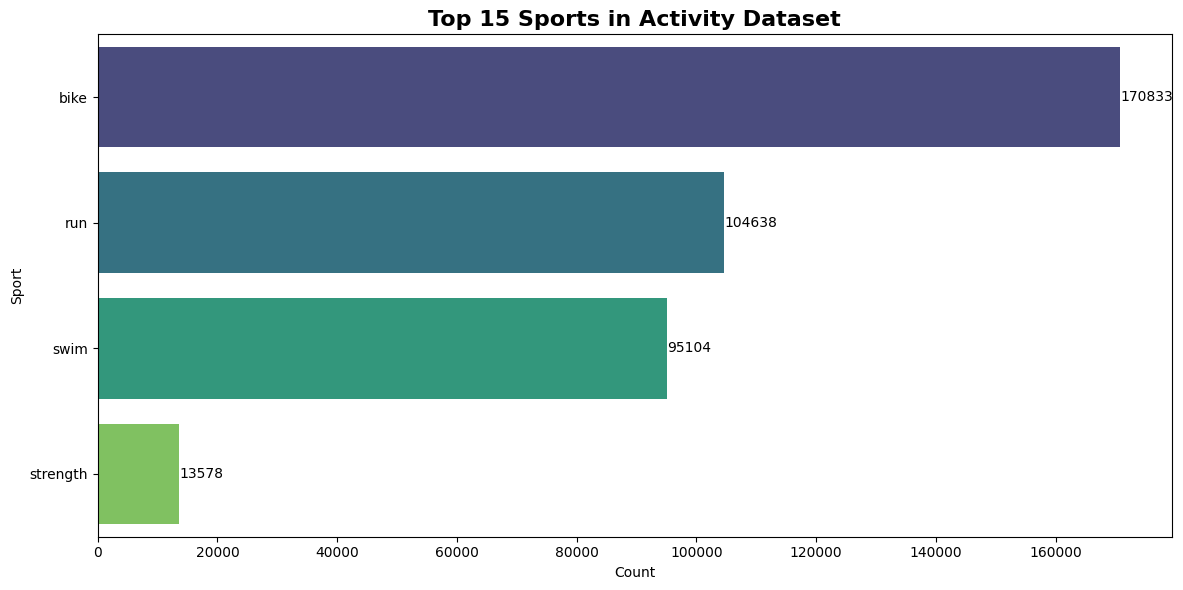

In [50]:
top_sports = activity["sport"].value_counts().head(15)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_sports.values, y=top_sports.index, palette="viridis")

plt.title("Top 15 Sports in Activity Dataset", fontsize=16, weight="bold")
plt.xlabel("Count")
plt.ylabel("Sport")

for i, v in enumerate(top_sports.values):
    ax.text(v + 5, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

## Exploratory Data Analysis - Injury Distribution

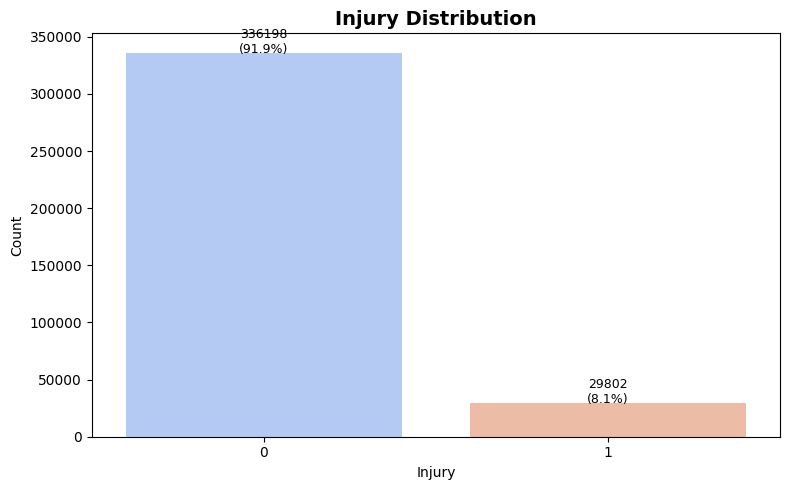

injury
0    91.857377
1     8.142623
Name: proportion, dtype: float64


In [51]:
injury_counts = daily["injury"].value_counts()
injury_pct = daily["injury"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=injury_counts.index, y=injury_counts.values, palette="coolwarm")

plt.title("Injury Distribution", fontsize=14, weight="bold")
plt.xlabel("Injury")
plt.ylabel("Count")

for i, v in enumerate(injury_counts.values):
    ax.text(i, v + 0.5, f"{v}\n({injury_pct.iloc[i]:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(injury_pct)

## Exploratory Data Analysis - Key Feature Correlation Heatmap

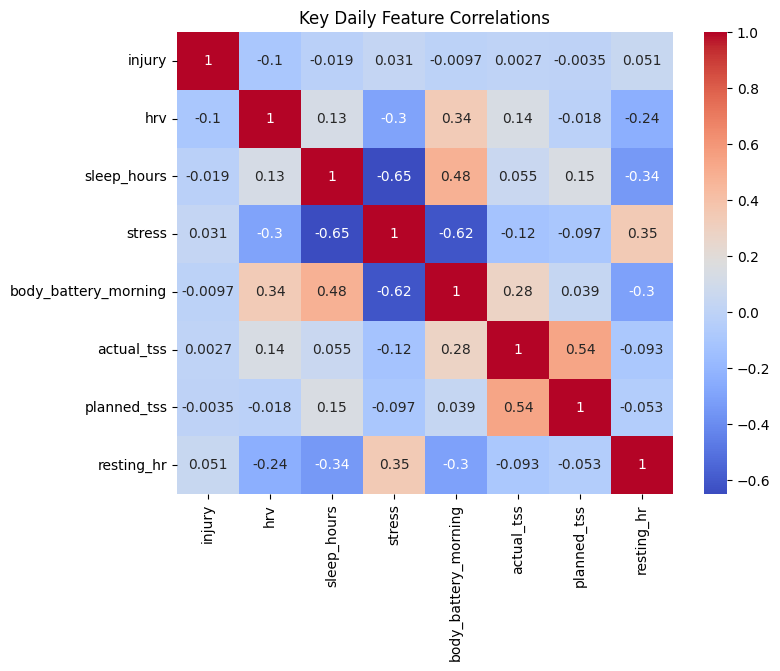

In [52]:
top_corr_cols = [
    "injury",
    "hrv",
    "sleep_hours",
    "stress",
    "body_battery_morning",
    "actual_tss",
    "planned_tss",
    "resting_hr"
]

corr = daily[top_corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Key Daily Feature Correlations")
plt.show()

## Data Preprocessing - Athlete Feature Parsing and Encoding

In [53]:
def parse_hrv_range(val):
    if pd.isna(val):
        return np.nan, np.nan
    s = str(val)
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", s)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return np.nan, np.nan

hrv_bounds = athletes["hrv_range"].apply(parse_hrv_range)

athletes["hrv_range_low"] = [x[0] for x in hrv_bounds]
athletes["hrv_range_high"] = [x[1] for x in hrv_bounds]

athletes["gender_enc"] = (
    athletes["gender"].astype(str).str.lower() == "male"
).astype(np.int8)

lifestyle_map = {
    "Highly Disciplined Athlete": 0,
    "Health-Conscious Athlete": 1,
    "Balanced Competitor": 2,
    "Under-Recovered Athlete": 3,
    "Sleep-Deprived Workaholic": 4,
    "Weekend Socializer": 5,
}

athletes["lifestyle_enc"] = athletes["lifestyle"].map(lifestyle_map).astype("float32")

athletes_clean = athletes.drop(
    columns=["hrv_range", "hr_zones", "gender", "lifestyle"],
    errors="ignore"
).copy()

print("athletes_clean:", athletes_clean.shape)

athletes_clean: (1000, 26)


## Feature Engineering - Activity Aggregation and Sport Encoding

In [54]:
sport_dummies = pd.get_dummies(activity["sport"].fillna("Unknown"), prefix="sport", dtype=np.int8)
act_dum = pd.concat([activity[["athlete_id", "date"]], sport_dummies], axis=1)
sport_counts = act_dum.groupby(["athlete_id", "date"], sort=False).sum().reset_index()

agg_dict = {
    "duration_minutes": ["sum", "mean", "max", "count"],
    "tss": ["sum", "mean", "max"],
    "intensity_factor": ["mean", "max"],
    "avg_hr": ["mean", "max"],
    "max_hr": "max",
    "distance_km": "sum",
    "elevation_gain": "sum",
    "training_effect_aerobic": "mean",
    "training_effect_anaerobic": "mean",
    "avg_power": "mean",
    "normalized_power": "mean",
    "work_kilojoules": "sum",
}

activity_agg = (
    activity.groupby(["athlete_id", "date"], sort=False)
    .agg(agg_dict)
    .reset_index()
)

activity_agg.columns = [
    "_".join(filter(None, col)) if isinstance(col, tuple) else col
    for col in activity_agg.columns
]

activity_agg = activity_agg.rename(columns={"duration_minutes_count": "sessions_total"})
activity_agg = activity_agg.merge(sport_counts, on=["athlete_id", "date"], how="left")

print("activity_agg:", activity_agg.shape)

activity_agg: (275527, 25)


## Data Integration - Master Dataset Construction

In [55]:
master = daily.merge(activity_agg, on=["athlete_id", "date"], how="left")

act_only_cols = [c for c in master.columns if c not in daily.columns]
master[act_only_cols] = master[act_only_cols].fillna(0)

master = master.merge(athletes_clean, on="athlete_id", how="left")
master = master.sort_values(["athlete_id", "date"]).reset_index(drop=True)
master = master.fillna(0)

print("master:", master.shape)
print("missing:", master.isnull().sum().sum())

master: (366000, 63)
missing: 0


## Feature Engineering - Temporal, Rolling Statistics, and Target Creation

In [56]:
def ensure_column(df, target_col, candidates):
    if target_col in df.columns:
        return
    for c in candidates:
        if c in df.columns:
            df[target_col] = df[c]
            return
    raise KeyError(f"Could not find {target_col}. Available resting-related cols: {[c for c in df.columns if 'resting' in c.lower()]}")

ensure_column(master, "daily_resting_hr", ["resting_hr_x", "resting_hr"])
ensure_column(master, "athlete_resting_hr", ["resting_hr_y", "resting_hr_athlete"])

master["day_of_year"] = master["date"].dt.dayofyear.astype(np.int16)
master["day_of_week"] = master["date"].dt.dayofweek.astype(np.int8)
master["month"] = master["date"].dt.month.astype(np.int8)

master["load_ratio"] = np.where(
    master["planned_tss"] > 0,
    master["actual_tss"] / master["planned_tss"],
    0.0
).astype(np.float32)

master["sleep_deficit"] = (master["sleep_time_norm"] - master["sleep_hours"]).astype(np.float32)
master["battery_drop"] = (master["body_battery_morning"] - master["body_battery_evening"]).astype(np.float32)
master["hrv_deficit"] = (master["hrv_baseline"] - master["hrv"]).astype(np.float32)
master["resting_hr_gap"] = (master["daily_resting_hr"] - master["athlete_resting_hr"]).astype(np.float32)

def add_group_rolling(df, group_col, base_col, windows, stats=("mean", "std")):
    g = df.groupby(group_col, sort=False)[base_col]
    for w in windows:
        if "mean" in stats:
            df[f"{base_col}_roll{w}_mean"] = g.transform(
                lambda s, w=w: s.shift(1).rolling(w, min_periods=1).mean()
            ).astype(np.float32)
        if "std" in stats:
            df[f"{base_col}_roll{w}_std"] = g.transform(
                lambda s, w=w: s.shift(1).rolling(w, min_periods=2).std()
            ).fillna(0).replace(0, 1).astype(np.float32)
        if "min" in stats:
            df[f"{base_col}_roll{w}_min"] = g.transform(
                lambda s, w=w: s.shift(1).rolling(w, min_periods=1).min()
            ).astype(np.float32)
        if "max" in stats:
            df[f"{base_col}_roll{w}_max"] = g.transform(
                lambda s, w=w: s.shift(1).rolling(w, min_periods=1).max()
            ).astype(np.float32)

roll_specs = {
    "actual_tss": [3, 7, 14, 28],
    "hrv": [3, 7, 14],
    "daily_resting_hr": [7, 14],
    "stress": [3, 7, 14],
    "sleep_hours": [3, 7, 14],
    "body_battery_morning": [3, 7, 14],
    "load_ratio": [7, 14],
    "sleep_deficit": [7, 14],
    "battery_drop": [7, 14],
}

for col, windows in roll_specs.items():
    if col in master.columns:
        add_group_rolling(master, "athlete_id", col, windows, stats=("mean", "std"))
    else:
        print(f"Skipping missing column: {col}")

if "actual_tss_roll7_mean" in master.columns and "actual_tss_roll28_mean" in master.columns:
    master["acwr"] = np.where(
        master["actual_tss_roll28_mean"] > 0,
        master["actual_tss_roll7_mean"] / master["actual_tss_roll28_mean"],
        0.0
    ).astype(np.float32)
else:
    master["acwr"] = 0.0

master["hrv_delta"] = (master["hrv"] - master["hrv_roll7_mean"]).astype(np.float32) if "hrv_roll7_mean" in master.columns else 0.0
master["stress_excess"] = (master["stress"] - master["stress_roll7_mean"]).astype(np.float32) if "stress_roll7_mean" in master.columns else 0.0
master["tss_spike"] = (master["actual_tss"] - master["actual_tss_roll7_mean"]).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0
master["battery_trend"] = (master["body_battery_morning"] - master["body_battery_morning_roll7_mean"]).astype(np.float32) if "body_battery_morning_roll7_mean" in master.columns else 0.0

master["tss_roll7_std"] = master["actual_tss_roll7_std"] if "actual_tss_roll7_std" in master.columns else 1.0
master["monotony"] = np.where(master["tss_roll7_std"] > 0, master["actual_tss_roll7_mean"] / master["tss_roll7_std"], 0.0).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0
master["strain"] = (master["actual_tss_roll7_mean"] * master["monotony"]).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0

master["injury_next3"] = (
    master.groupby("athlete_id", sort=False)["injury"]
    .transform(lambda x: x.shift(-1).rolling(3, min_periods=1).max())
).fillna(0).astype(np.int8)

print("Feature engineering complete")
print(master.shape)
print(master[["daily_resting_hr", "athlete_resting_hr", "resting_hr_gap"]].head())
print(master["injury_next3"].value_counts())
print(master["injury_next3"].value_counts(normalize=True).round(4))

Feature engineering complete
(366000, 130)
   daily_resting_hr  athlete_resting_hr  resting_hr_gap
0         51.912317                48.2        3.712317
1         50.246351                48.2        2.046351
2         50.834952                48.2        2.634952
3         51.825352                48.2        3.625352
4         51.691678                48.2        3.491678
injury_next3
0    327358
1     38642
Name: count, dtype: int64
injury_next3
0    0.8944
1    0.1056
Name: proportion, dtype: float64


## Feature Selection and Target Definition

In [57]:
DROP_REDUNDANT = [
    "resting_hr_x",
    "resting_hr_y",
    "sleep_quality_x",
    "sleep_quality_y"
]

master = master.drop(columns=DROP_REDUNDANT, errors="ignore")

DROP_COLS = {
    "athlete_id",
    "date",
    "injury",
    "injury_next3",
    "running_threshold_pace",
}

FEATURE_COLS = [
    c for c in master.columns
    if c not in DROP_COLS and pd.api.types.is_numeric_dtype(master[c])
]

TARGET_COL = "injury_next3"

print("Total features:", len(FEATURE_COLS))
print(FEATURE_COLS[:20])

Total features: 121
['hrv', 'sleep_hours', 'deep_sleep', 'light_sleep', 'rem_sleep', 'body_battery_morning', 'stress', 'body_battery_evening', 'planned_tss', 'actual_tss', 'duration_minutes_sum', 'duration_minutes_mean', 'duration_minutes_max', 'sessions_total', 'tss_sum', 'tss_mean', 'tss_max', 'intensity_factor_mean', 'intensity_factor_max', 'avg_hr_mean']


## Subject-Aware Train/Validation/Test Split and Feature Scaling

In [58]:
athlete_ids = master["athlete_id"].drop_duplicates().to_numpy()
rng = np.random.default_rng(SEED)
rng.shuffle(athlete_ids)

n = len(athlete_ids)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_ids = athlete_ids[:n_train]
val_ids   = athlete_ids[n_train:n_train + n_val]
test_ids  = athlete_ids[n_train + n_val:]

train_df = master[master["athlete_id"].isin(train_ids)].copy()
val_df   = master[master["athlete_id"].isin(val_ids)].copy()
test_df  = master[master["athlete_id"].isin(test_ids)].copy()

print(f"Train: {train_df.shape} | athletes: {train_df['athlete_id'].nunique()}")
print(f"Val  : {val_df.shape} | athletes: {val_df['athlete_id'].nunique()}")
print(f"Test : {test_df.shape} | athletes: {test_df['athlete_id'].nunique()}")

scaler = StandardScaler()

for df in [train_df, val_df, test_df]:
    df[FEATURE_COLS] = (
        df[FEATURE_COLS]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(np.float32)
    )

train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
val_df[FEATURE_COLS]   = scaler.transform(val_df[FEATURE_COLS])
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print("Scaling complete")

Train: (256200, 126) | athletes: 700
Val  : (54900, 126) | athletes: 150
Test : (54900, 126) | athletes: 150
Scaling complete


## Sequence Dataset Construction and DataLoader Preparation

In [59]:
SEQ_LEN = 30

class AthleteSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, seq_len=30):
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.X_groups = []
        self.y_groups = []
        self.sample_map = []

        grouped = df.groupby("athlete_id", sort=False)

        for group_idx, (_, group) in enumerate(grouped):
            group = group.sort_values("date").reset_index(drop=True)

            X = group[feature_cols].to_numpy(dtype=np.float32, copy=True)
            y = group[target_col].to_numpy(dtype=np.float32, copy=True)

            self.X_groups.append(X)
            self.y_groups.append(y)

            for end_idx in range(seq_len, len(group)):
                self.sample_map.append((group_idx, end_idx))

    def __len__(self):
        return len(self.sample_map)

    def __getitem__(self, idx):
        group_idx, end_idx = self.sample_map[idx]
        X = self.X_groups[group_idx][end_idx - self.seq_len:end_idx]
        y = self.y_groups[group_idx][end_idx]
        return torch.from_numpy(X), torch.tensor(y, dtype=torch.float32)

NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"
BATCH_SIZE = 512 if DEVICE.type == "cuda" else 128

train_ds = AthleteSequenceDataset(train_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)
val_ds   = AthleteSequenceDataset(val_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)
test_ds  = AthleteSequenceDataset(test_df, FEATURE_COLS, TARGET_COL, SEQ_LEN)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print(f"Train sequences: {len(train_ds):,}")
print(f"Val sequences  : {len(val_ds):,}")
print(f"Test sequences : {len(test_ds):,}")

pos = int(train_df[TARGET_COL].sum())
neg = int((train_df[TARGET_COL] == 0).sum())
raw_pos_weight = neg / max(pos, 1)
pos_weight = torch.tensor([min(raw_pos_weight, 5.0)], dtype=torch.float32, device=DEVICE)
print(f"pos_weight: {pos_weight.item():.2f}")

Train sequences: 235,200
Val sequences  : 50,400
Test sequences : 50,400
pos_weight: 5.00


## Model Architecture Definition - Hybrid TCN, BiGRU, Transformer, and Attention Pooling

In [60]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class ResidualTCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.BatchNorm1d(out_channels)
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        res = self.residual(x)

        out = self.conv1(x)
        out = out[:, :, :x.size(2)]
        out = F.gelu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out[:, :, :x.size(2)]
        out = self.norm(out)

        return F.gelu(out + res)


class HybridInjuryModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=4, tf_layers=2, gru_hidden=64, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.tcn1 = ResidualTCNBlock(d_model, d_model, dilation=1, dropout=dropout)
        self.tcn2 = ResidualTCNBlock(d_model, d_model, dilation=2, dropout=dropout)

        self.bigru = nn.GRU(
            input_size=d_model,
            hidden_size=gru_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.post_gru_norm = nn.LayerNorm(gru_hidden * 2)
        self.pos_enc = PositionalEncoding(gru_hidden * 2, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=gru_hidden * 2,
            nhead=nhead,
            dim_feedforward=(gru_hidden * 2) * 3,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=tf_layers)

        self.attn_pool = nn.Linear(gru_hidden * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        x = self.tcn1(x)
        x = self.tcn2(x)
        x = x.transpose(1, 2)

        x, _ = self.bigru(x)
        x = self.post_gru_norm(x)
        x = self.pos_enc(x)
        x = self.transformer(x)

        attn_w = torch.softmax(self.attn_pool(x), dim=1)
        x = (x * attn_w).sum(dim=1)

        return self.classifier(x).squeeze(-1)


INPUT_DIM = len(FEATURE_COLS)
model = HybridInjuryModel(
    input_dim=INPUT_DIM,
    d_model=128,
    nhead=4,
    tf_layers=2,
    gru_hidden=64,
    dropout=0.2
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Trainable parameters: 629,634
HybridInjuryModel(
  (input_proj): Sequential(
    (0): Linear(in_features=121, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (tcn1): ResidualTCNBlock(
    (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,))
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,))
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual): Identity()
  )
  (tcn2): ResidualTCNBlock(
    (conv1): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
    (dropout): Dropout(p=0.2, inplace=False)
    (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual): Identity()
 

## Training Setup - Loss Function, Optimizer, Scheduler, and Mixed Precision Configuration

In [61]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

EPOCHS = 25
PATIENCE = 5
MIN_DELTA = 1e-4

scheduler = OneCycleLR(
    optimizer,
    max_lr=2e-4,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10.0,
    final_div_factor=100.0,
    anneal_strategy="cos"
)

scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print("=" * 70)
print("Training setup ready")
print("=" * 70)
print(f"Device: {DEVICE}")
print(f"Epochs: {EPOCHS}")
print(f"Patience: {PATIENCE}")
print("=" * 70)

Training setup ready
Device: cuda
Epochs: 25
Patience: 5


## Training Loop - Epoch Execution, Validation, Metrics Tracking, and Early Stopping

In [62]:
def run_epoch(loader, train=True):
    mode = "Train" if train else "Validation"
    model.train() if train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if USE_AMP else nullcontext()
    pbar = tqdm(loader, desc=mode, leave=False)

    if train:
        for X, y in pbar:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).view(-1)

            optimizer.zero_grad(set_to_none=True)

            with amp_ctx:
                logits = model(X).view(-1)
                loss = criterion(logits, y)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            scheduler.step()

            total_loss += loss.item() * y.size(0)
            probs = torch.sigmoid(logits).detach().float().cpu().numpy()
            all_preds.append(probs)
            all_labels.append(y.detach().float().cpu().numpy())

            pbar.set_postfix(
                loss=f"{loss.item():.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
                gn=f"{float(grad_norm):.2f}"
            )
    else:
        with torch.inference_mode():
            for X, y in pbar:
                X = X.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True).view(-1)

                with amp_ctx:
                    logits = model(X).view(-1)
                    loss = criterion(logits, y)

                total_loss += loss.item() * y.size(0)
                probs = torch.sigmoid(logits).detach().float().cpu().numpy()
                all_preds.append(probs)
                all_labels.append(y.detach().float().cpu().numpy())

                pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_pred_prob = np.concatenate(all_preds).reshape(-1)
    y_true = np.concatenate(all_labels).reshape(-1)

    avg_loss = total_loss / len(loader.dataset)

    try:
        auroc = roc_auc_score(y_true, y_pred_prob)
    except Exception:
        auroc = 0.5

    try:
        auprc = average_precision_score(y_true, y_pred_prob)
    except Exception:
        auprc = 0.5

    return avg_loss, auroc, auprc


history = {
    "train_loss": [],
    "val_loss": [],
    "train_auroc": [],
    "val_auroc": [],
    "val_auprc": []
}

best_val_auprc = -np.inf
best_epoch = -1
patience_count = 0

print("\nStarting training...\n")

for epoch in range(1, EPOCHS + 1):
    print("=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 80)

    tr_loss, tr_auroc, tr_auprc = run_epoch(train_loader, train=True)
    vl_loss, vl_auroc, vl_auprc = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_auroc"].append(tr_auroc)
    history["val_auroc"].append(vl_auroc)
    history["val_auprc"].append(vl_auprc)

    improved = vl_auprc > (best_val_auprc + MIN_DELTA)

    if improved:
        best_val_auprc = vl_auprc
        best_epoch = epoch
        patience_count = 0
        torch.save(model.state_dict(), "/content/best_model.pt")
        print("Best model saved.")
    else:
        patience_count += 1

    print(
        f"Train Loss: {tr_loss:.4f} | Train AUROC: {tr_auroc:.4f} | Train AUPRC: {tr_auprc:.4f}\n"
        f"Val Loss  : {vl_loss:.4f} | Val AUROC  : {vl_auroc:.4f} | Val AUPRC  : {vl_auprc:.4f}\n"
        f"Patience  : {patience_count}/{PATIENCE}"
    )

    if patience_count >= PATIENCE:
        print("Early stopping triggered.")
        break

print("=" * 80)
print("Training complete")
print("=" * 80)
print(f"Best epoch: {best_epoch}")
print(f"Best validation AUPRC: {best_val_auprc:.4f}")


Starting training...

Epoch 1/25


Train:   0%|          | 0/459 [00:00<?, ?it/s]

Validation:   0%|          | 0/99 [00:00<?, ?it/s]

Best model saved.
Train Loss: 0.7217 | Train AUROC: 0.8167 | Train AUPRC: 0.5323
Val Loss  : 0.5059 | Val AUROC  : 0.9021 | Val AUPRC  : 0.7723
Patience  : 0/5
Epoch 2/25


Train:   0%|          | 0/459 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/99 [00:00<?, ?it/s]

Train Loss: 0.2128 | Train AUROC: 0.9769 | Train AUPRC: 0.9448
Val Loss  : 0.3057 | Val AUROC  : 0.9452 | Val AUPRC  : 0.9114
Patience  : 4/5
Epoch 10/25


Train:   0%|          | 0/459 [00:00<?, ?it/s]

Validation:   0%|          | 0/99 [00:00<?, ?it/s]

Train Loss: 0.1940 | Train AUROC: 0.9816 | Train AUPRC: 0.9524
Val Loss  : 0.3303 | Val AUROC  : 0.9430 | Val AUPRC  : 0.9084
Patience  : 5/5
Early stopping triggered.
Training complete
Best epoch: 5
Best validation AUPRC: 0.9169


## Training Visualization - Loss, AUROC, and AUPRC Curves with Best Epoch Highlight

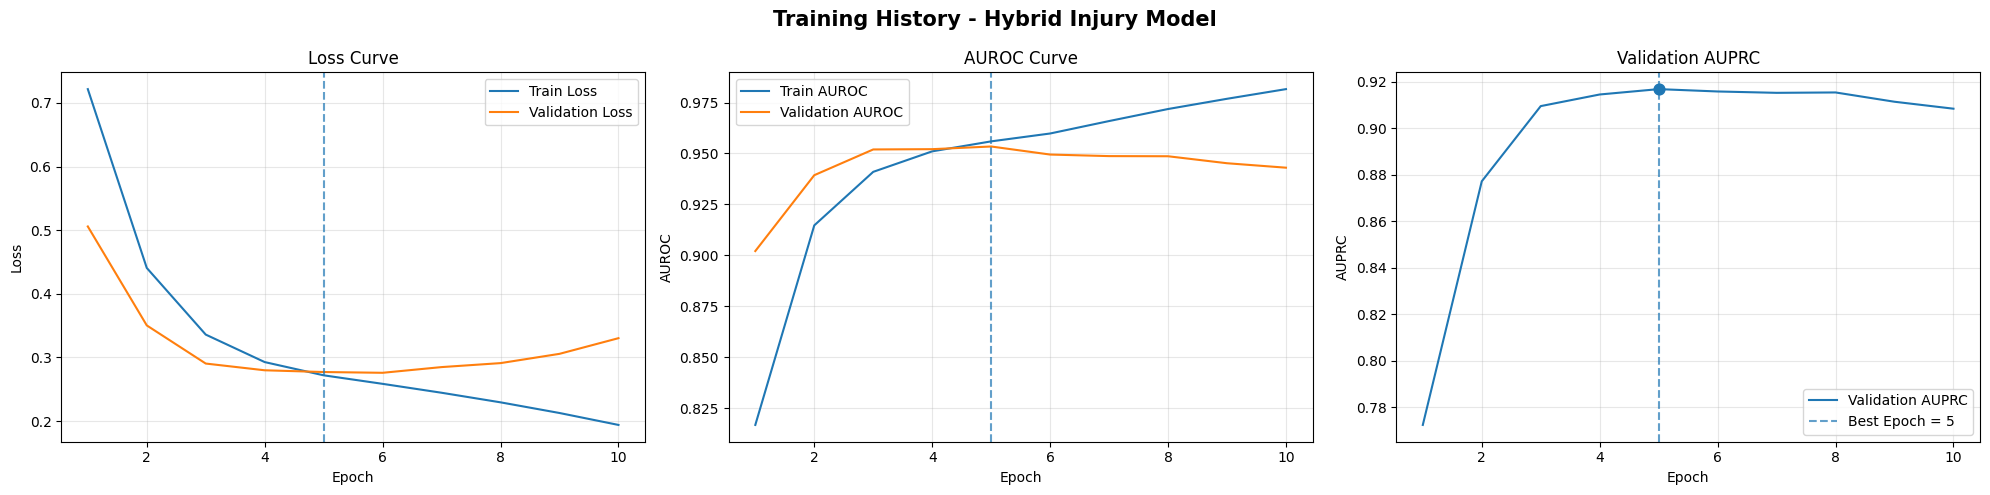

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Training History - Hybrid Injury Model", fontsize=15, fontweight="bold")

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_ran, history["val_loss"], label="Validation Loss")
axes[0].axvline(best_epoch, linestyle="--", alpha=0.7)
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_auroc"], label="Train AUROC")
axes[1].plot(epochs_ran, history["val_auroc"], label="Validation AUROC")
axes[1].axvline(best_epoch, linestyle="--", alpha=0.7)
axes[1].set_title("AUROC Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history["val_auprc"], label="Validation AUPRC")
axes[2].axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best Epoch = {best_epoch}")
axes[2].scatter(best_epoch, history["val_auprc"][best_epoch - 1], s=60)
axes[2].set_title("Validation AUPRC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUPRC")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Evaluation - Threshold Tuning, Test Metrics, and Classification Report

In [64]:
model.load_state_dict(torch.load("/content/best_model.pt", map_location=DEVICE))
model.eval()

amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if USE_AMP else nullcontext()

val_preds = []
val_labels = []

with torch.inference_mode():
    for X, y in val_loader:
        X = X.to(DEVICE, non_blocking=True)

        with amp_ctx:
            logits = model(X)
            probs = torch.sigmoid(logits).float().cpu().numpy()

        val_preds.append(probs)
        val_labels.append(y.numpy())

val_pred_prob = np.concatenate(val_preds).reshape(-1)
val_true = np.concatenate(val_labels).reshape(-1)

thresholds = np.arange(0.05, 0.96, 0.01)

val_f1s = [
    f1_score(val_true, (val_pred_prob >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_thresh = thresholds[int(np.argmax(val_f1s))]

val_recalls = [
    recall_score(val_true, (val_pred_prob >= t).astype(int), zero_division=0)
    for t in thresholds
]
recall_thresh = thresholds[int(np.argmax(val_recalls))]

print(f"Best F1 Threshold      : {best_thresh:.2f}")
print(f"Best Recall Threshold  : {recall_thresh:.2f}")

all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_loader:
        X = X.to(DEVICE, non_blocking=True)

        with amp_ctx:
            logits = model(X)
            probs = torch.sigmoid(logits).float().cpu().numpy()

        all_preds.append(probs)
        all_labels.append(y.numpy())

y_pred_prob = np.concatenate(all_preds).reshape(-1)
y_true = np.concatenate(all_labels).reshape(-1)

FINAL_THRESH = best_thresh

y_pred = (y_pred_prob >= FINAL_THRESH).astype(int)

test_auroc = roc_auc_score(y_true, y_pred_prob)
test_auprc = average_precision_score(y_true, y_pred_prob)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
brier = brier_score_loss(y_true, y_pred_prob)

print("=" * 70)
print("Test Set Evaluation")
print("=" * 70)

print(f"Final Threshold Used  : {FINAL_THRESH:.2f}")
print(f"AUROC                : {test_auroc:.4f}")
print(f"AUPRC                : {test_auprc:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"F1 Score             : {f1:.4f}")
print(f"Brier Score          : {brier:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["No Injury", "Injury"]
))

Best F1 Threshold      : 0.88
Best Recall Threshold  : 0.05
Test Set Evaluation
Final Threshold Used  : 0.88
AUROC                : 0.9511
AUPRC                : 0.9129
Precision            : 0.9293
Recall               : 0.8360
Specificity          : 0.9914
F1 Score             : 0.8802
Brier Score          : 0.0319

Classification Report:

              precision    recall  f1-score   support

   No Injury       0.98      0.99      0.98     44425
      Injury       0.93      0.84      0.88      5975

    accuracy                           0.97     50400
   macro avg       0.95      0.91      0.93     50400
weighted avg       0.97      0.97      0.97     50400



## Evaluation Visualization - Confusion Matrix, ROC Curve, and Precision-Recall Curve

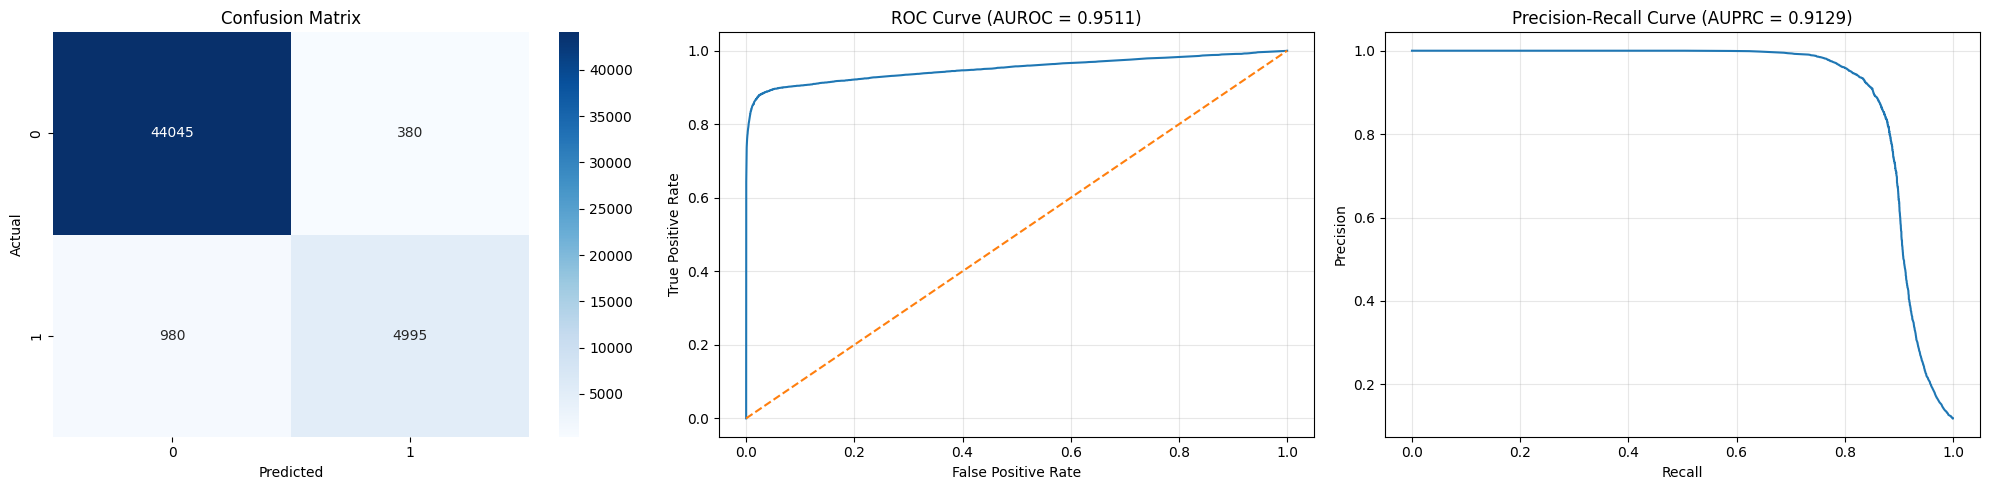

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
axes[1].plot(fpr, tpr)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title(f"ROC Curve (AUROC = {test_auroc:.4f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)

precisions, recalls, _ = precision_recall_curve(y_true, y_pred_prob)
axes[2].plot(recalls, precisions)
axes[2].set_title(f"Precision-Recall Curve (AUPRC = {test_auprc:.4f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## Comprehensive Evaluation Dashboard - ROC, PR Curve, Confusion Matrix, Calibration, and Training Insights

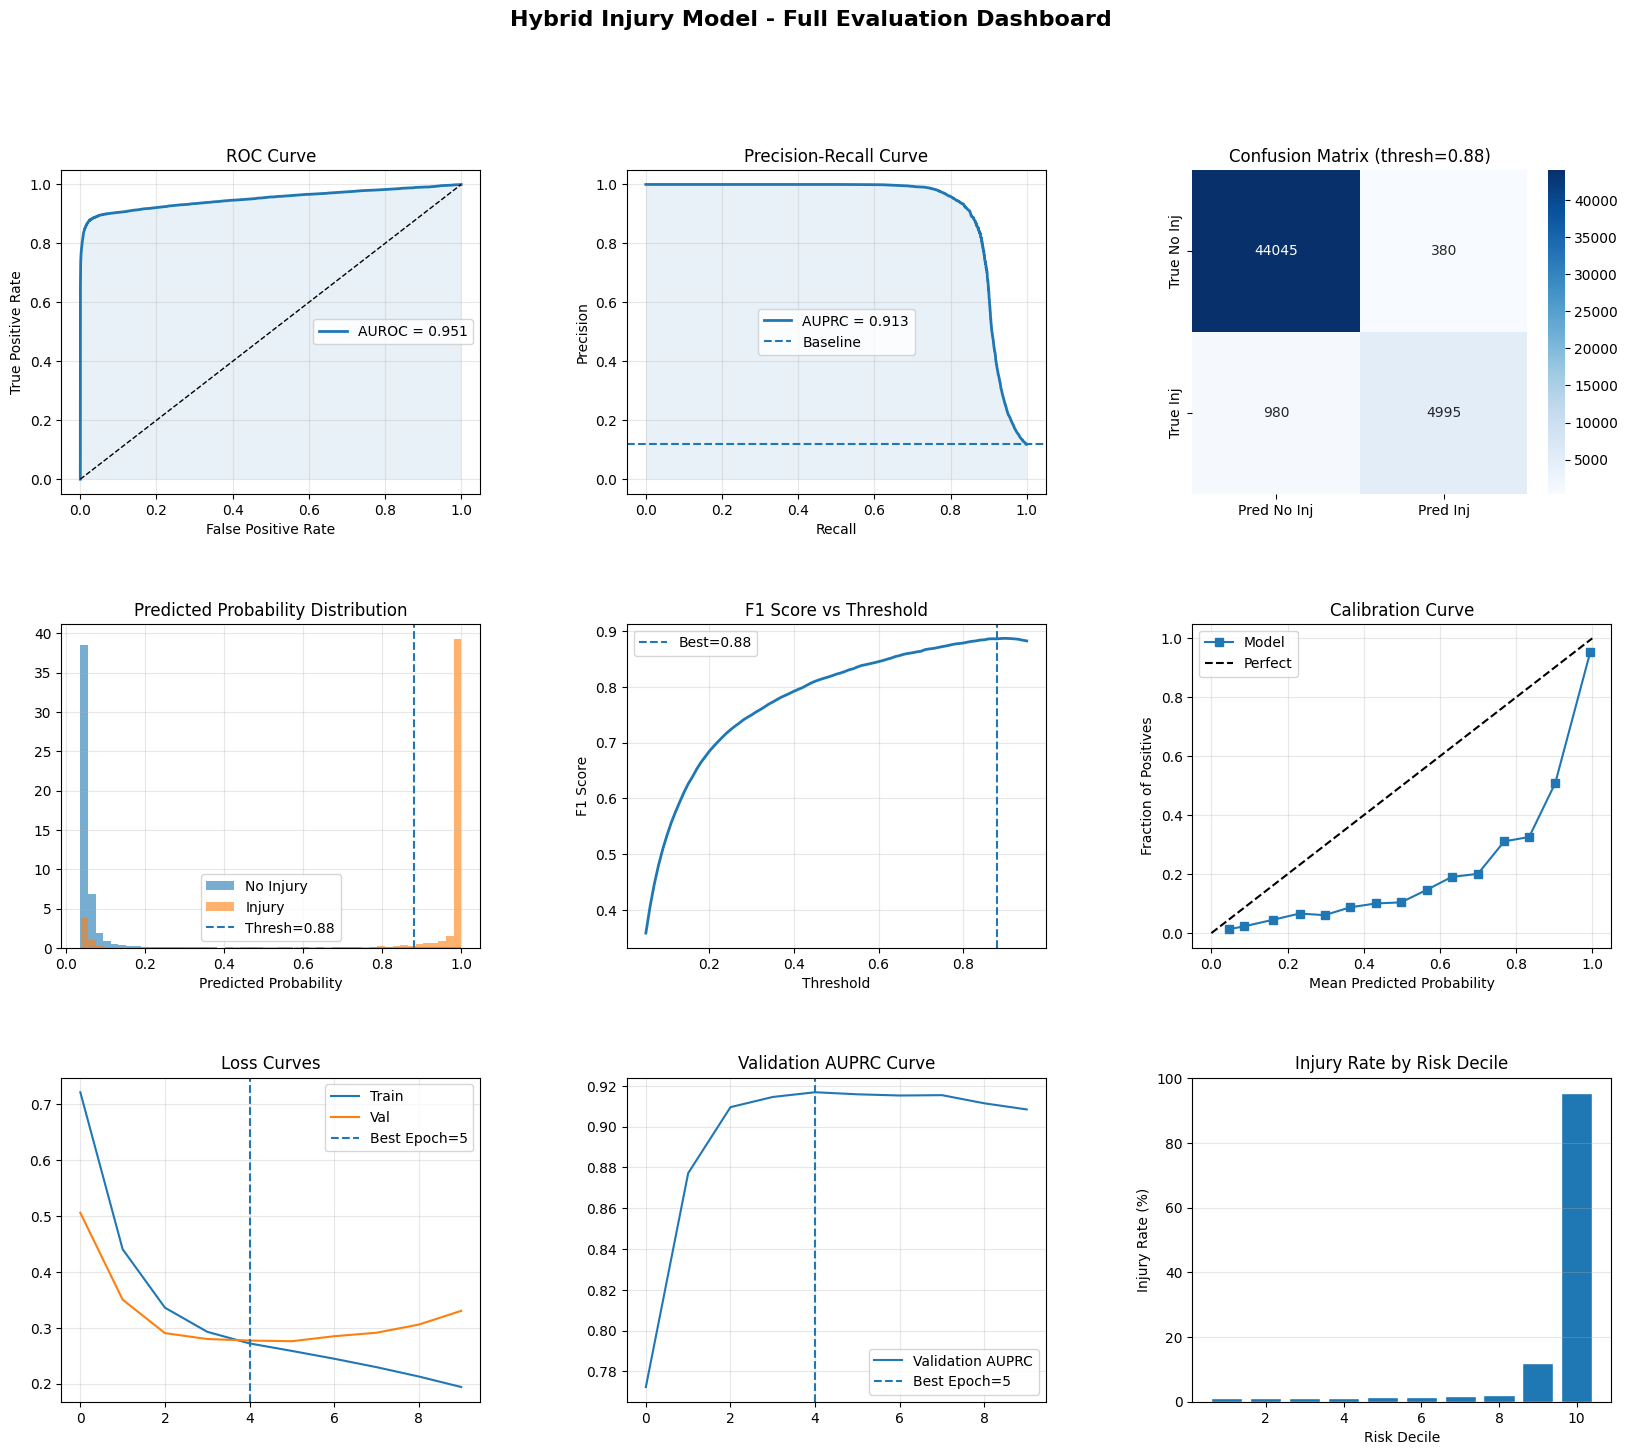

In [66]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("Hybrid Injury Model - Full Evaluation Dashboard", fontsize=16, fontweight="bold")

best_epoch_idx = int(np.argmax(history["val_auprc"])) + 1

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, linewidth=2, label=f"AUROC = {test_auroc:.3f}")
ax1.plot([0, 1], [0, 1], "k--", linewidth=1)
ax1.fill_between(fpr, tpr, alpha=0.1)
ax1.set_title("ROC Curve")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(recalls, precisions, linewidth=2, label=f"AUPRC = {test_auprc:.3f}")
ax2.axhline(y_true.mean(), linestyle="--", label="Baseline")
ax2.fill_between(recalls, precisions, alpha=0.1)
ax2.set_title("Precision-Recall Curve")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax3,
    xticklabels=["Pred No Inj", "Pred Inj"],
    yticklabels=["True No Inj", "True Inj"]
)
ax3.set_title(f"Confusion Matrix (thresh={best_thresh:.2f})")

ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_pred_prob[y_true == 0], bins=50, alpha=0.6, density=True, label="No Injury")
ax4.hist(y_pred_prob[y_true == 1], bins=50, alpha=0.6, density=True, label="Injury")
ax4.axvline(best_thresh, linestyle="--", label=f"Thresh={best_thresh:.2f}")
ax4.set_title("Predicted Probability Distribution")
ax4.set_xlabel("Predicted Probability")
ax4.legend()
ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(thresholds, f1s, linewidth=2)
ax5.axvline(best_thresh, linestyle="--", label=f"Best={best_thresh:.2f}")
ax5.set_title("F1 Score vs Threshold")
ax5.set_xlabel("Threshold")
ax5.set_ylabel("F1 Score")
ax5.legend()
ax5.grid(alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
frac_pos = []
mean_pred = []
bins = np.linspace(0, 1, 16)
bin_ids = np.digitize(y_pred_prob, bins) - 1
for b in range(len(bins) - 1):
    mask = bin_ids == b
    if mask.sum() > 0:
        frac_pos.append(y_true[mask].mean())
        mean_pred.append(y_pred_prob[mask].mean())
ax6.plot(mean_pred, frac_pos, "s-", label="Model")
ax6.plot([0, 1], [0, 1], "k--", label="Perfect")
ax6.set_title("Calibration Curve")
ax6.set_xlabel("Mean Predicted Probability")
ax6.set_ylabel("Fraction of Positives")
ax6.legend()
ax6.grid(alpha=0.3)

ax7 = fig.add_subplot(gs[2, 0])
ax7.plot(history["train_loss"], label="Train")
ax7.plot(history["val_loss"], label="Val")
ax7.axvline(best_epoch_idx - 1, linestyle="--", label=f"Best Epoch={best_epoch_idx}")
ax7.set_title("Loss Curves")
ax7.legend()
ax7.grid(alpha=0.3)

ax8 = fig.add_subplot(gs[2, 1])
ax8.plot(history["val_auprc"], label="Validation AUPRC")
ax8.axvline(best_epoch_idx - 1, linestyle="--", label=f"Best Epoch={best_epoch_idx}")
ax8.set_title("Validation AUPRC Curve")
ax8.legend()
ax8.grid(alpha=0.3)

ax9 = fig.add_subplot(gs[2, 2])
deciles = pd.qcut(pd.Series(y_pred_prob).rank(method="first"), 10, labels=False)
decile_df = pd.DataFrame({"decile": deciles, "injury": y_true})
decile_rate = decile_df.groupby("decile")["injury"].mean() * 100
ax9.bar(decile_rate.index + 1, decile_rate.values, edgecolor="white")
ax9.set_title("Injury Rate by Risk Decile")
ax9.set_xlabel("Risk Decile")
ax9.set_ylabel("Injury Rate (%)")
ax9.grid(alpha=0.3, axis="y")

plt.savefig("/content/evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving Artifacts - Model, Scaler, Features, Config, Training History, and Predictions

In [67]:
artifacts = {
    "scaler.pkl": scaler,
    "feature_cols.pkl": FEATURE_COLS,
    "best_threshold.pkl": best_thresh,
    "model_config.json": {
        "seq_len": SEQ_LEN,
        "input_dim": INPUT_DIM,
        "d_model": 128,
        "nhead": 4,
        "tf_layers": 2,
        "gru_hidden": 64,
        "dropout": 0.2,
    },
    "history.pkl": history,
    "master.parquet": master,
    "test_predictions.csv": pd.DataFrame({
        "y_true": y_true,
        "y_pred_prob": y_pred_prob,
        "y_pred": y_pred
    })
}

with open("/content/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("/content/feature_cols.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)

with open("/content/best_threshold.pkl", "wb") as f:
    pickle.dump(best_thresh, f)

with open("/content/model_config.json", "w") as f:
    json.dump(artifacts["model_config.json"], f, indent=2)

with open("/content/history.pkl", "wb") as f:
    pickle.dump(history, f)

master.to_parquet("/content/master.parquet", index=False)
artifacts["test_predictions.csv"].to_csv("/content/test_predictions.csv", index=False)

print("Saved:")
print("/content/best_model.pt")
print("/content/scaler.pkl")
print("/content/feature_cols.pkl")
print("/content/best_threshold.pkl")
print("/content/model_config.json")
print("/content/history.pkl")
print("/content/master.parquet")
print("/content/test_predictions.csv")

Saved:
/content/best_model.pt
/content/scaler.pkl
/content/feature_cols.pkl
/content/best_threshold.pkl
/content/model_config.json
/content/history.pkl
/content/master.parquet
/content/test_predictions.csv


## End-to-End Data Preparation Function - From Raw CSVs to Fully Engineered Master Dataset

In [68]:
def prepare_master_from_raw(athletes_path, daily_path, activity_path):
    athletes = pd.read_csv(athletes_path)
    daily = pd.read_csv(daily_path)
    activity = pd.read_csv(activity_path)

    daily["date"] = pd.to_datetime(daily["date"])
    activity["date"] = pd.to_datetime(activity["date"])

    hrv_bounds = athletes["hrv_range"].apply(parse_hrv_range)
    athletes["hrv_range_low"] = [x[0] for x in hrv_bounds]
    athletes["hrv_range_high"] = [x[1] for x in hrv_bounds]
    athletes["gender_enc"] = (athletes["gender"].astype(str).str.lower() == "male").astype(np.int8)
    athletes["lifestyle_enc"] = athletes["lifestyle"].map(lifestyle_map).astype("float32")

    athletes_clean = athletes.drop(columns=["hrv_range", "hr_zones", "gender", "lifestyle"], errors="ignore").copy()

    sport_dummies = pd.get_dummies(activity["sport"].fillna("Unknown"), prefix="sport", dtype=np.int8)
    act_dum = pd.concat([activity[["athlete_id", "date"]], sport_dummies], axis=1)
    sport_counts = act_dum.groupby(["athlete_id", "date"], sort=False).sum().reset_index()

    activity_agg = (
        activity.groupby(["athlete_id", "date"], sort=False)
        .agg(agg_dict)
        .reset_index()
    )
    activity_agg.columns = [
        "_".join(filter(None, col)) if isinstance(col, tuple) else col
        for col in activity_agg.columns
    ]
    activity_agg = activity_agg.rename(columns={"duration_minutes_count": "sessions_total"})
    activity_agg = activity_agg.merge(sport_counts, on=["athlete_id", "date"], how="left")

    master = daily.merge(activity_agg, on=["athlete_id", "date"], how="left")
    act_only_cols = [c for c in master.columns if c not in daily.columns]
    master[act_only_cols] = master[act_only_cols].fillna(0)

    master = master.merge(athletes_clean, on="athlete_id", how="left")
    master = master.sort_values(["athlete_id", "date"]).reset_index(drop=True)
    master = master.fillna(0)

    ensure_column(master, "daily_resting_hr", ["resting_hr_x", "resting_hr"])
    ensure_column(master, "athlete_resting_hr", ["resting_hr_y", "resting_hr_athlete"])

    master["day_of_year"] = master["date"].dt.dayofyear.astype(np.int16)
    master["day_of_week"] = master["date"].dt.dayofweek.astype(np.int8)
    master["month"] = master["date"].dt.month.astype(np.int8)

    master["load_ratio"] = np.where(master["planned_tss"] > 0, master["actual_tss"] / master["planned_tss"], 0.0).astype(np.float32)
    master["sleep_deficit"] = (master["sleep_time_norm"] - master["sleep_hours"]).astype(np.float32)
    master["battery_drop"] = (master["body_battery_morning"] - master["body_battery_evening"]).astype(np.float32)
    master["hrv_deficit"] = (master["hrv_baseline"] - master["hrv"]).astype(np.float32)
    master["resting_hr_gap"] = (master["daily_resting_hr"] - master["athlete_resting_hr"]).astype(np.float32)

    for col, windows in roll_specs.items():
        if col in master.columns:
            add_group_rolling(master, "athlete_id", col, windows, stats=("mean", "std"))

    if "actual_tss_roll7_mean" in master.columns and "actual_tss_roll28_mean" in master.columns:
        master["acwr"] = np.where(master["actual_tss_roll28_mean"] > 0, master["actual_tss_roll7_mean"] / master["actual_tss_roll28_mean"], 0.0).astype(np.float32)
    else:
        master["acwr"] = 0.0

    master["hrv_delta"] = (master["hrv"] - master["hrv_roll7_mean"]).astype(np.float32) if "hrv_roll7_mean" in master.columns else 0.0
    master["stress_excess"] = (master["stress"] - master["stress_roll7_mean"]).astype(np.float32) if "stress_roll7_mean" in master.columns else 0.0
    master["tss_spike"] = (master["actual_tss"] - master["actual_tss_roll7_mean"]).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0
    master["battery_trend"] = (master["body_battery_morning"] - master["body_battery_morning_roll7_mean"]).astype(np.float32) if "body_battery_morning_roll7_mean" in master.columns else 0.0

    master["tss_roll7_std"] = master["actual_tss_roll7_std"] if "actual_tss_roll7_std" in master.columns else 1.0
    master["monotony"] = np.where(master["tss_roll7_std"] > 0, master["actual_tss_roll7_mean"] / master["tss_roll7_std"], 0.0).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0
    master["strain"] = (master["actual_tss_roll7_mean"] * master["monotony"]).astype(np.float32) if "actual_tss_roll7_mean" in master.columns else 0.0

    master = master.replace([np.inf, -np.inf], np.nan).fillna(0)
    return master

## Inference Function - Predict Latest Injury Risk for a Given Athlete Sequence

In [69]:
def predict_latest_risk(master_df, athlete_id, feature_cols, seq_len, model, scaler, threshold=0.5):
    athlete_df = master_df[master_df["athlete_id"] == athlete_id].sort_values("date").copy()
    if len(athlete_df) < seq_len:
        raise ValueError(f"Athlete {athlete_id} has only {len(athlete_df)} rows; need at least {seq_len}")

    seq = athlete_df[feature_cols].tail(seq_len).replace([np.inf, -np.inf], np.nan).fillna(0)
    seq = scaler.transform(seq)
    X = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.inference_mode():
        logit = model(X).item()
        prob = float(torch.sigmoid(torch.tensor(logit)).item())

    pred = int(prob >= threshold)
    risk_band = "High" if prob >= 0.75 else "Medium" if prob >= 0.5 else "Low"

    return {
        "athlete_id": athlete_id,
        "risk_prob": prob,
        "pred_label": pred,
        "risk_band": risk_band,
        "threshold": threshold
    }

## Final Results Summary - Key Metrics, Threshold, Model Size, and Feature Configuration

In [70]:
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Test AUROC     : {test_auroc:.4f}")
print(f"Test AUPRC     : {test_auprc:.4f}")
print(f"Best threshold : {best_thresh:.2f}")
print(f"Model params   : {total_params:,}")
print(f"Seq length     : {SEQ_LEN} days")
print(f"Feature count  : {len(FEATURE_COLS)}")
print("=" * 60)

FINAL RESULTS SUMMARY
Test AUROC     : 0.9511
Test AUPRC     : 0.9129
Best threshold : 0.88
Model params   : 629,634
Seq length     : 30 days
Feature count  : 121
